TokaMaker Example: Ballooning-limited pedestal height in negative triangularity with GPEC
==========
In this example we demonstrate how to couple TokaMaker to [GPEC](https://github.com/OpenFUSIONToolkit/GPEC) (the Generalized Perturbed Equilibrium Code) in order to estimate the **pedestal height that a negative triangularity (NT) plasma can support**, as limited by ideal infinite-n ballooning modes. This is done in several steps:

1) Reproduce the DIII-D NT equilibrium of [DIII-D baseline example](../../DIIID/DIIID_baseline_ex.ipynb) (shot 192185 at 2440 ms) from its gEQDSK file.
2) Evaluate TokaMaker's cheap, local NT H-mode access proxy (`eval_NT_H_proxy()`) as a first look at edge ballooning stability.
3) Build a family of H-mode kinetic profiles that scan the pedestal height at fixed shape and plasma current, and compute a bootstrap-consistent equilibrium for each one with `solve_with_bootstrap()`.
4) Hand each equilibrium to GPEC as a gEQDSK and compute the ideal infinite-n (ballooning) stability boundary: the experimental pressure-gradient drive $\alpha(\psi_N)$ against the critical $\alpha_{crit}(\psi_N)$ at which $\Delta'$ first changes sign.
5) Interpolate the pedestal height at which the edge first crosses that boundary. Because an NT edge has no access to the second stable region, this first boundary is the operative limit, and the marginal pedestal height is an estimate of the pedestal the plasma can actually sustain.

**Note:** This example uses external tools, and is not part of the automatically tested example suite. In addition to the usual python packages (see `requirements_NT_Ballooning_GPEC.txt`) it requires a working [Julia](https://julialang.org/) installation and a local copy of the GPEC repository. See `README.md` in this folder for setup instructions.

In [1]:
import os
import sys
import json
import subprocess
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

### Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk, create_power_flux_fun, eval_NT_H_proxy
from OpenFUSIONToolkit.TokaMaker.bootstrap import solve_with_bootstrap, Hmode_profiles

### Locate the external GPEC installation

GPEC is a Julia package that is developed alongside OFT but distributed separately, so it is treated here the same way the TokaMaker+TORAX pulse design workflow treats TORAX: as an external module that the user installs and points the notebook at. The cell below looks for the GPEC project directory (the folder containing GPEC's `Project.toml`) in the following order:
1. The `GPEC_PROJECT` environment variable,
2. `external/GPEC` in any parent directory (the location used when GPEC is added to a repository as a git submodule),
3. A `GPEC` clone sitting next to the OpenFUSIONToolkit checkout. 

See `README.md` for how to obtain and instantiate GPEC.

In [3]:
def find_gpec_project():
    r'''Locate the GPEC Julia project (the directory containing GPEC's Project.toml)'''
    candidates = []
    if os.getenv('GPEC_PROJECT') is not None:
        candidates.append(os.getenv('GPEC_PROJECT'))
    search_dir = os.path.abspath(os.getcwd())
    for _ in range(8):
        candidates.append(os.path.join(search_dir,'external','GPEC'))
        candidates.append(os.path.join(search_dir,'GPEC'))
        search_dir = os.path.dirname(search_dir)
    for candidate in candidates:
        if os.path.isfile(os.path.join(candidate,'Project.toml')):
            return os.path.abspath(candidate)
    raise FileNotFoundError('Could not locate GPEC. Set the "GPEC_PROJECT" environment variable '
                            'to the GPEC repository, or see README.md for setup instructions.')

GPEC_PROJECT = find_gpec_project()
print('GPEC project:  {0}'.format(GPEC_PROJECT))
print('Julia version: {0}'.format(subprocess.run(['julia','--version'],capture_output=True,text=True).stdout.strip()))

GPEC project:  /Users/hansec/Research/GPEC_julia
Julia version: julia version 1.13.0


### Define GPEC ballooning function

GPEC can be run from Python in one of two ways: 1) Directly through the use of the [juliacall](https://juliapy.github.io/PythonCall.jl/stable/) module (see README.md for this example for instructions) or 2) Indirectly via an intermediate script using the `subprocess` module (see `compute_ballooning_boundary.jl` in this example). Here we demonstrate the use of both methods, with a preference for `juliacall` if available. For both you must ensure that your environment is setup properly to find the necessary Julia environment and modules (eg. specify the `--project` argument or set the `PYTHON_JULIACALL_PROJECT` environment variable). 

In [4]:
try:
    # Setup environment so juliacall can find GPEC
    os.environ['PYTHON_JULIACALL_EXE'] = subprocess.run(['which','julia'],capture_output=True,text=True).stdout.strip()
    os.environ['PYTHON_JULIACALL_PROJECT'] = GPEC_PROJECT
    os.environ['PYTHON_JULIACALL_THREADS'] = 'auto'
    os.environ['PYTHON_JULIACALL_HANDLE_SIGNALS'] = 'yes'
    
    # Setup GPEC through juliacall
    import juliacall
    jl = juliacall.newmodule("TokaMaker_GPEC")
    jl.seval("using GeneralizedPerturbedEquilibrium")
    jl.seval("using GeneralizedPerturbedEquilibrium: Equilibrium, LocalStability")

    def run_gpec_ballooning(geqdsk_paths, both_boundaries=False):
        r'''Compute ballooning boundary(ies) using GPEC for a list of gEQDSK files'''
        print('Running GPEC using juliacall')
        for geqdsk_path in geqdsk_paths:
            geqdsk_path = os.path.abspath(geqdsk_path)
            geqdsk_file = os.path.basename(geqdsk_path)
            geqdsk_dir = os.path.abspath(os.path.dirname(geqdsk_path))
            
            # Build GPEC equilibrium object
            eq_dict = {
                "eq_filename": geqdsk_path,
                "eq_type": "efit",
                "jac_type": "hamada",
                "grid_type": "log_asymptotic",
                "psilow": 1e-4,
                "psihigh": 0.9995,
                "mpsi": 0,
                "psi_accuracy": 0.001,
                "mtheta": 256,
                "newq0": 0,
                "etol": 1e-10,
            }
            # Python dictionaries are Dict[Any, Any] by default but GPEC requires Dict[String, Any]
            # so we need to explicitly convert before passing it
            jl_dict = juliacall.convert(jl.Dict[jl.String, jl.Any], eq_dict)
            eq_config = jl.Equilibrium.EquilibriumConfig(jl_dict, geqdsk_dir)
            equil = jl.Equilibrium.setup_equilibrium(eq_config)
            
            # Solve for lower or both stability boundaries?
            if both_boundaries:
                bnd = jl.LocalStability.ballooning_alpha_boundaries(equil, n_scan=64)
                output_dict = {
                    'psi': list(bnd.psi),
                    'alpha': list(bnd.alpha),
                    'alpha_critical': list(bnd.alpha_critical1),
                    'alpha_critical2': list(bnd.alpha_critical2),
                }
            else:
                bnd = jl.LocalStability.ballooning_alpha_boundary(equil, n_scan=64)
                output_dict = {
                    'psi': list(bnd.psi),
                    'alpha': list(bnd.alpha),
                    'alpha_critical': list(bnd.alpha_critical)
                }

            # Save output in same format as external process script
            with open("ballooning_boundary_{0}.json".format(geqdsk_file), "w") as f:
                json.dump(output_dict, f, indent=4)
except:
    def run_gpec_ballooning(geqdsk_paths, both_boundaries=False):
        r'''Run the GPEC ballooning boundary driver on a list of gEQDSK files'''
        print('Running GPEC as external process')
        cmd = ['julia','-t','auto','--project={0}'.format(GPEC_PROJECT),'compute_ballooning_boundary.jl']
        if both_boundaries:
            cmd.append('--both')
        cmd = cmd + list(geqdsk_paths)
        print('  ' + ' '.join(cmd))
        proc = subprocess.run(cmd, capture_output=True, text=True)
        print(proc.stdout)
        if proc.returncode != 0:
            print(proc.stderr[-4000:])
            raise RuntimeError('GPEC ballooning calculation failed')

### Reproduce the DIII-D NT equilibrium

We start from the same DIII-D negative triangularity discharge used in [DIII-D baseline example](../../DIIID/DIIID_baseline_ex.ipynb), reusing the gEQDSK and the mesh built in [DIII-D meshing example](../../DIIID/DIIID_mesh_ex.ipynb) from the `DIIID` example folder. The equilibrium is reproduced with an inverse solve, where the last closed flux surface from the gEQDSK is imposed as an `isoflux` constraint and the EFIT coil currents are imposed through the coil regularization terms.

In [5]:
DIIID_dir = os.path.join('..','..','DIIID')
eqdsk = read_eqdsk(os.path.join(DIIID_dir,'g192185.02440'))

In [6]:
myOFT = OFT_env(nthreads=4)
mygs = TokaMaker(myOFT)
mygs.settings.maxits = 400

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        v26.9
Development branch:  ballooning_with_gpec
Revision id:         e3ae8f67

Parallelization Info:
  # of MPI tasks      =    1
  # of NUMA nodes     =    1
  # of OpenMP threads =    4

Linear Algebra backend: native

#----------------------------------------------



In [7]:
mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh(os.path.join(DIIID_dir,'DIIID_mesh.h5'))
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order=2,F0=eqdsk['rcentr']*eqdsk['bcentr'])
mygs.set_coil_vsc({'F9A': 1.0, 'F9B': -1.0})


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    8911
    # of edges   =   26570
    # of cells   =   17660
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  8.702E-04
    hrms =  4.833E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1733


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.6370000000000000E-003


The target coil currents and regularization weights are those of [DIII-D baseline example](../../DIIID/DIIID_baseline_ex.ipynb).

In [8]:
target_currents = {
    'ECOILA': -16030.961914062493,
    'ECOILB': -15782.150390625,
    'F1A': 1999.5169719827586,
    'F2A': 1031.1705953663793,
    'F3A': -530.3450296336207,
    'F4A': -691.5127963362069,
    'F5A': 12.465672986260776,
    'F6A': -2142.877414772727,
    'F7A': 620.4805397727273,
    'F8A': -975.8820716594828,
    'F9A': 4302.279545454546,
    'F1B': 2213.2513469827586,
    'F2B': 1316.7264278017242,
    'F3B': -385.2729660560345,
    'F4B': -2295.533943965517,
    'F5B': 6.891535265692344,
    'F6B': -2792.180113636364,
    'F7B': 754.6947443181818,
    'F8B': -886.030239762931,
    'F9B': 4588.732102272727,
}

# Set regularization weights
regularization_terms = []
for name, target_current in target_currents.items():
    if name.startswith('ECOIL'):
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=target_current,weight=61.0))
    elif name.startswith('F5'):
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=target_current,weight=1.E2))
    else:
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=target_current,weight=1.E0))
# Set zero target current and small weight on virtual VSC to allow up-down adjustment
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E-2))

mygs.set_coil_reg(reg_terms=regularization_terms)

In [9]:
mygs.set_isoflux_constraints(eqdsk['rzout'].copy())
mygs.set_targets(Ip=eqdsk['ip'], pax=eqdsk['pres'][0])

# Use the P' and FF' profiles from the gEQDSK for the baseline solve
psi_sample = np.linspace(0.0,1.0,50)
psi_eqdsk = np.linspace(0.0,1.0,np.size(eqdsk['ffprim']))
mygs.set_profiles(ffp_prof={'type': 'linterp', 'x': psi_sample, 'y': np.interp(psi_sample,psi_eqdsk,eqdsk['ffprim'])},
                  pp_prof={'type': 'linterp', 'x': psi_sample, 'y': np.interp(psi_sample,psi_eqdsk,eqdsk['pprime'])})

In [10]:
mygs.init_psi(1.7, 0.0, 0.5, 1.3, -0.4)
_ = mygs.solve()

Starting non-linear GS solver
     1 -1.0370E+00 -2.6299E-06  3.7449E-03  1.7835E+00 -3.9857E-02 -3.3739E+02
     2 -1.4700E+00 -1.6804E-06  2.4761E-03  1.7822E+00 -3.9770E-02 -1.2199E+02
     3 -1.6973E+00 -1.4436E-06  1.5610E-03  1.7814E+00 -3.9551E-02 -4.1269E+01
     4 -1.8257E+00 -1.3512E-06  8.6427E-04  1.7810E+00 -3.9293E-02  3.2934E+00
     5 -1.8984E+00 -1.3082E-06  4.8483E-04  1.7807E+00 -3.9037E-02  2.9221E+01
     6 -1.9393E+00 -1.2864E-06  2.5588E-04  1.7806E+00 -3.8802E-02  3.8686E+01
     7 -1.9620E+00 -1.2750E-06  1.4923E-04  1.7805E+00 -3.8596E-02  4.7866E+01
     8 -1.9747E+00 -1.2689E-06  7.9490E-05  1.7804E+00 -3.8421E-02  5.1701E+01
     9 -1.9816E+00 -1.2656E-06  4.6709E-05  1.7803E+00 -3.8273E-02  5.4556E+01
    10 -1.9855E+00 -1.2638E-06  3.2259E-05  1.7803E+00 -3.8152E-02  5.7270E+01
    11 -1.9875E+00 -1.2628E-06  1.6944E-05  1.7803E+00 -3.8053E-02  5.8341E+01
    12 -1.9886E+00 -1.2623E-06  1.1932E-05  1.7803E+00 -3.7972E-02  5.9310E+01
    13 -1.9892E+00 -1.

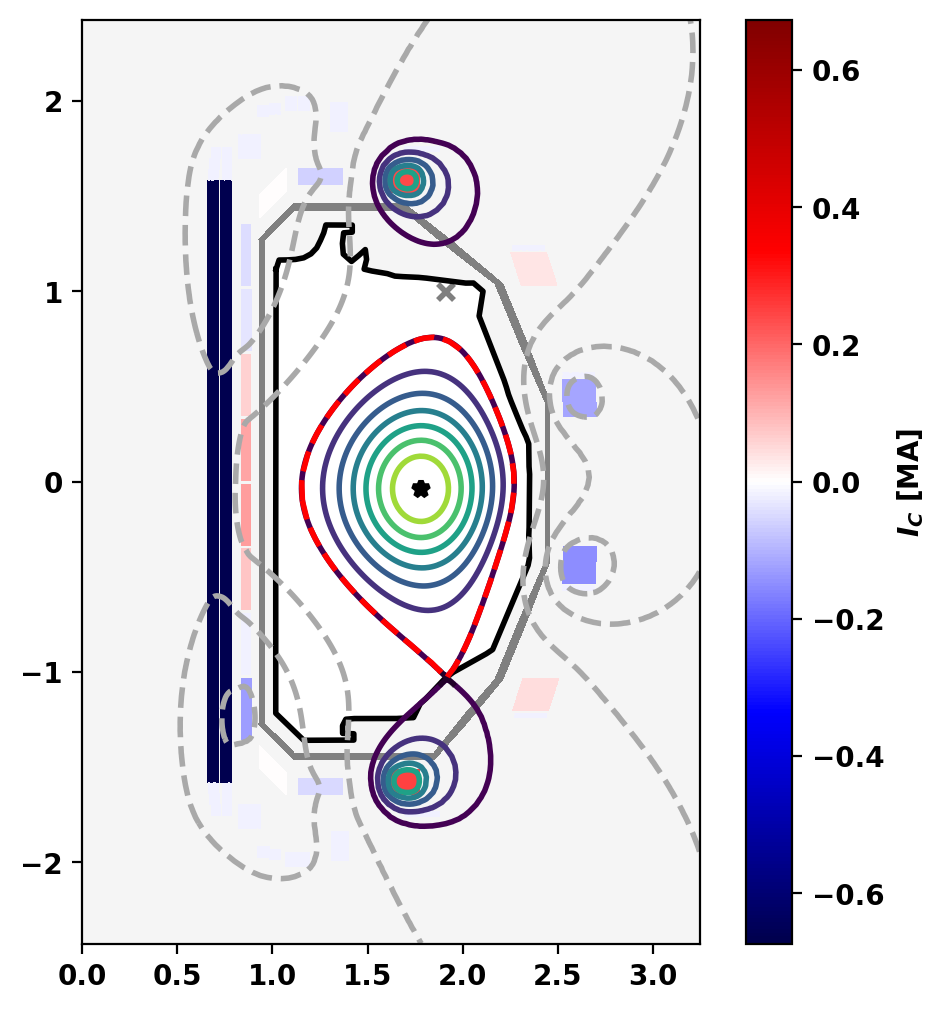

In [11]:
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]')
mygs.plot_psi(fig,ax,vacuum_nlevels=4)
_ = ax.plot(eqdsk['rzout'][:,0], eqdsk['rzout'][:,1],'r--')

In [12]:
mygs.print_info()

Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    4.9332E+05
  Current Centroid [m]    =    1.758 -0.044
  Magnetic Axis [m]       =    1.780 -0.038
  Elongation              =    1.594 (U:  1.423, L:  1.765)
  Triangularity           =   -0.297 (U: -0.228, L: -0.366)
  Plasma Volume [m^3]     =   14.567
  q_0, q_95               =    0.858  5.475
  Plasma Pressure [Pa]    =   Axis:  6.8216E+03, Peak:  6.8216E+03
  Stored Energy [J]       =    3.9875E+04
  <Beta_pol> [%]          =   23.3445
  <Beta_tor> [%]          =    0.1274
  <Beta_n>   [%]          =    0.2738
  Diamagnetic flux [Wb]   =    6.1160E-03
  Toroidal flux [Wb]      =    2.5371E+00
  l_i                     =    1.6230


### A first look at edge ballooning stability

Before running GPEC we evaluate the local NT H-mode access proxy `eval_NT_H_proxy()`, which approximates infinite-n ballooning stability of a near-edge surface by asking whether the point of maximum local shear (see `calc_local_shear()`) sits in the good or bad curvature region [[A.O. Nelson et al., Nucl. Fusion 62, 096020 (2022)](https://doi.org/10.1088/1741-4326/ac8064)]. This is a purely geometric criterion: it says whether the surface is favourably arranged for ballooning stability, which is a proxy for whthere or not ELM-free conditioons will be accessed. 

Lower half of psi_N = 0.9 surface: unfavourable (ballooning limited)
Upper half of psi_N = 0.9 surface: unfavourable (ballooning limited)


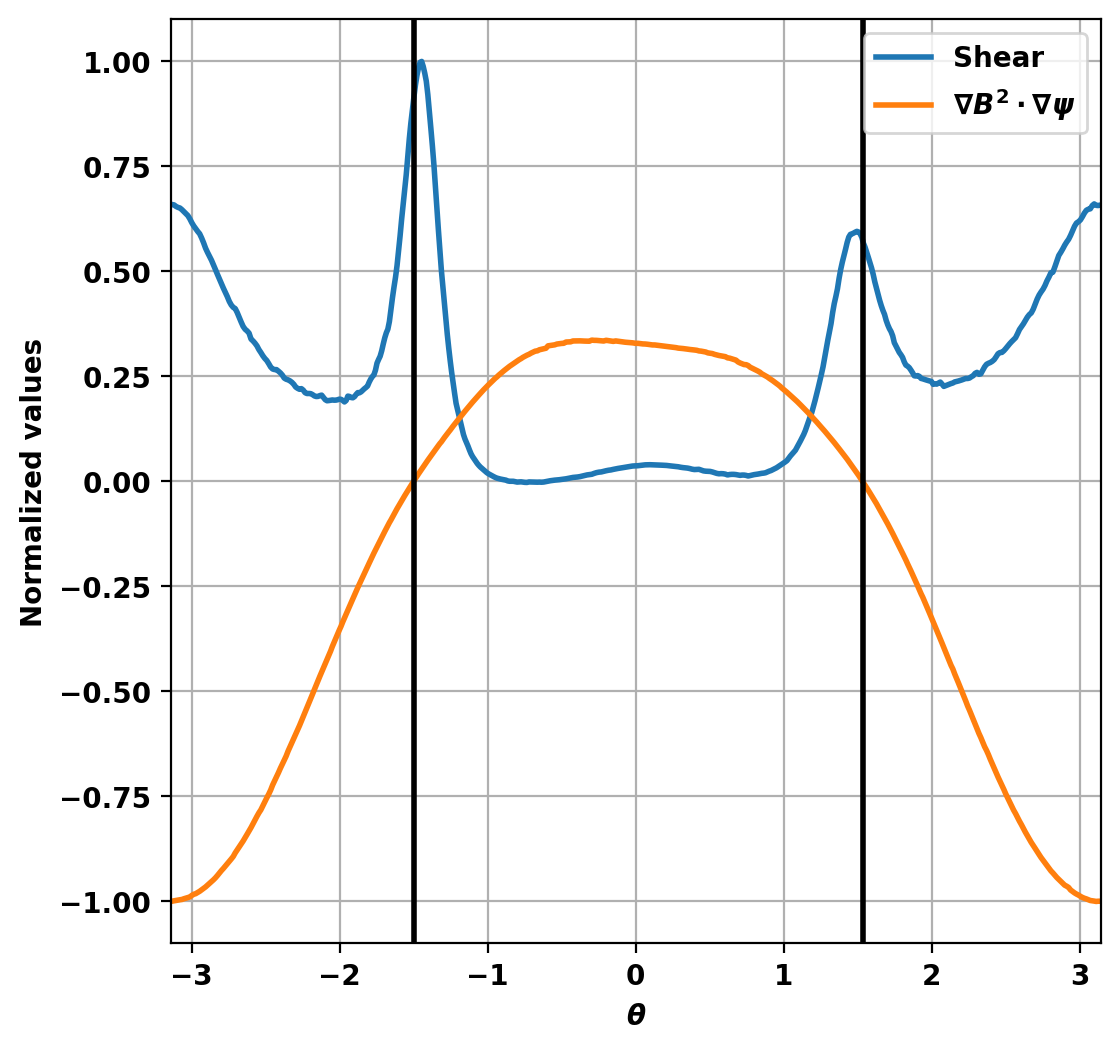

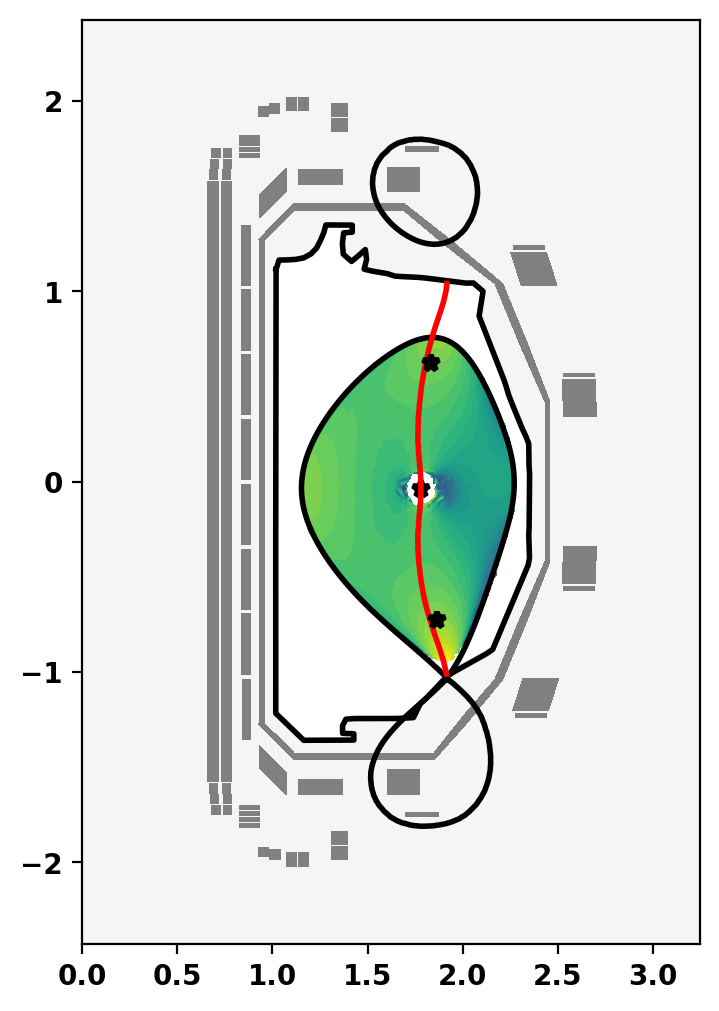

In [13]:
fig_1d, ax_1d = plt.subplots(1,1)
fig_2d, ax_2d = plt.subplots(1,1)
mygs.plot_machine(fig_2d,ax_2d)
mygs.plot_psi(fig_2d,ax_2d,xpoint_color=None,plasma_levels=[1.0],vacuum_nlevels=0,plasma_color='k')
access_lower, access_upper = eval_NT_H_proxy(mygs._tMaker_equil, psi_surf=0.9, ax_1d=ax_1d, ax_2d=ax_2d)
for name, access in (('Lower',access_lower), ('Upper',access_upper)):
    print('{0} half of psi_N = 0.9 surface: {1}'.format(
        name, 'favourable (H-mode access expected)' if access else 'unfavourable (ballooning limited)'))

### Build a family of pedestals

We now scan the pedestal height at fixed boundary shape and plasma current. Kinetic profiles are built with the OMFIT-style `Hmode_profiles()` parametrization (`Hmode_profiles()`), which is also used in [ITER H-mode example](../../ITER/ITER_Hmode_ex.ipynb).

For this example, the density profile is held fixed across the scan, so the pedestal height is scanned through the temperature. We further set $T_e = T_i$, with the core value tied to the pedestal value by a fixed ratio, i.e. a stiff-core transport assumption in which the core rides on top of whatever pedestal is achieved. The pedestal width is held fixed here. In a full EPED-like calculation the width would be tied to $\beta_{p,ped}$ and the peeling-ballooning (finite-n) boundary could be used; this example deliberately isolates the infinite-n ballooning constraint, which is the one that dominates in NT.

In [14]:
EC = 1.602176634e-19

n_psi = 201
psi_N = np.linspace(0.0,1.0,n_psi)

Ip_target = abs(eqdsk['ip'])
ped_width = 0.05    # Pedestal width in normalized flux
core_ratio = 3.5    # T_core/T_ped (stiff core)

# Fixed density profile [m^-3]
ne_prof = Hmode_profiles(edge=0.8e19, ped=2.5e19, core=4.0e19, rgrid=n_psi,
                         expin=1.5, expout=1.5, widthp=ped_width)
# Flat Zeff, typical of DIII-D L/H-mode discharges
Zeff_prof = np.full(n_psi, 2.0)

def profiles_for_pedestal(Te_ped):
    r'''Kinetic profiles for a given pedestal temperature [eV], assuming Te = Ti and ni = ne'''
    Te_prof = Hmode_profiles(edge=0.15*Te_ped, ped=Te_ped, core=core_ratio*Te_ped, rgrid=n_psi,
                             expin=1.5, expout=1.5, widthp=ped_width)
    p_prof = 2.0*EC*ne_prof*Te_prof
    return Te_prof, p_prof

# Pedestal temperatures to scan [eV]
Te_peds = np.array([100.0, 140.0, 180.0, 220.0, 260.0])

# Pedestal top, taken just inside the pedestal knee
i_ped = np.argmin(abs(psi_N - (1.0 - 2.0*ped_width)))
def pedestal_pressure(p_prof):
    return p_prof[i_ped]

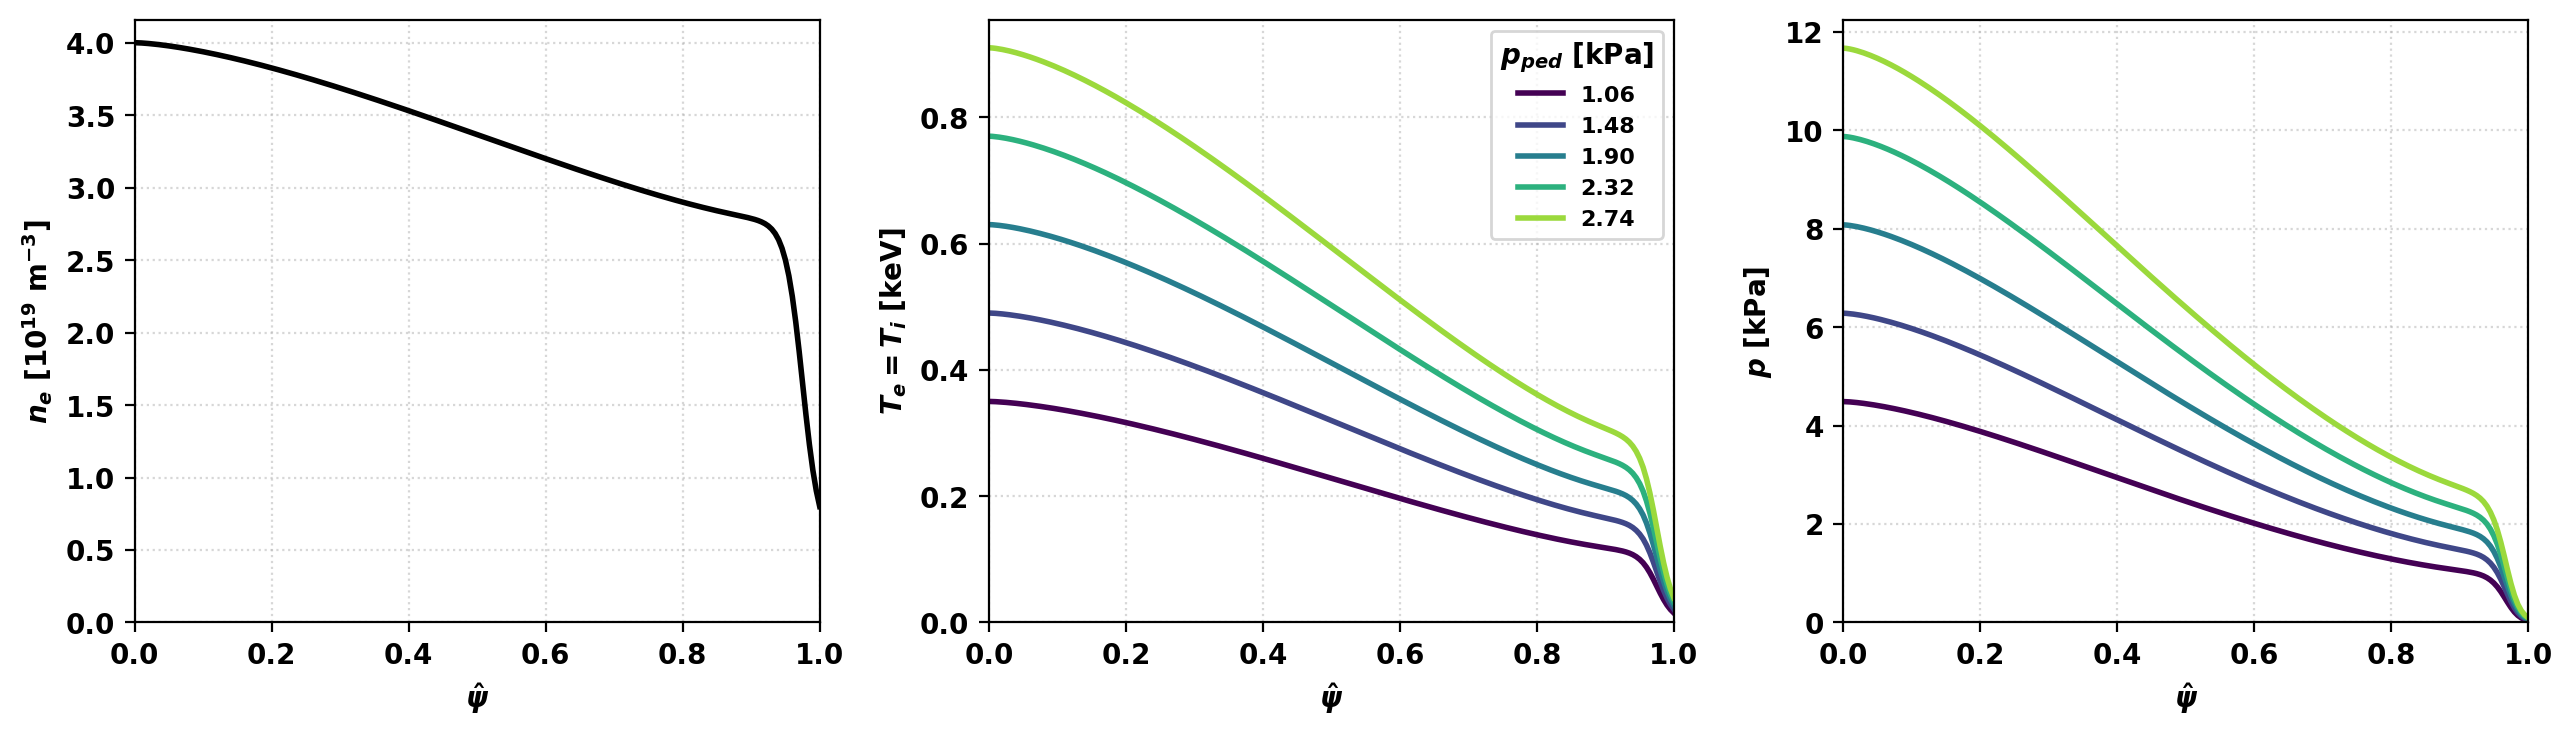

In [15]:
fig, ax = plt.subplots(1,3,figsize=(13,3.8))
colors = plt.cm.viridis(np.linspace(0.0,0.85,len(Te_peds)))
ax[0].plot(psi_N, ne_prof/1.E19, color='k')
for Te_ped, color in zip(Te_peds,colors):
    Te_prof, p_prof = profiles_for_pedestal(Te_ped)
    ax[1].plot(psi_N, Te_prof/1.E3, color=color, label='{0:.2F}'.format(pedestal_pressure(p_prof)/1.E3))
    ax[2].plot(psi_N, p_prof/1.E3, color=color)
ax[0].set_ylabel(r'$n_e$ [$10^{19}$ m$^{-3}$]')
ax[1].set_ylabel(r'$T_e = T_i$ [keV]')
ax[2].set_ylabel(r'$p$ [kPa]')
ax[1].legend(title=r'$p_{ped}$ [kPa]',fontsize=8)
for axis in ax:
    axis.set_xlabel(r'$\hat{\psi}$')
    axis.set_xlim(0.0,1.0)
    axis.set_ylim(bottom=0.0)
    axis.grid(ls=':',alpha=0.5)
fig.tight_layout()

### Solve a bootstrap-consistent equilibrium for each pedestal

Each case restarts from the baseline $\psi$ and is solved with `solve_with_bootstrap()`, which evaluates the bootstrap current from the kinetic profiles, isolates its pedestal spike, and rescales the inductive current so that $j_{ind} + j_{BS}$ integrates to the target $I_p$. The equilibrium is then solved in TokaMaker's `jphi-linterp` mode, so $FF'$ is reconstructed self-consistently with the bootstrap current rather than being prescribed. This matters for the stability calculation: the pedestal bootstrap current raises the local magnetic shear, which feeds directly back into the ballooning boundary evaluated below. 

Each converged equilibrium is written out as a gEQDSK in `ballooning_scan/`, which is the interface to GPEC.

In [16]:
# Save the baseline solution so every case in the scan starts from the same state
psi_baseline = mygs.get_psi(False).copy()

mygs.settings.maxits = 800
mygs.settings.pm = False
mygs.update_settings()

# Normalized inductive current shape used as the initial guess; solve_with_bootstrap
# rescales it internally to match Ip_target
guess_jind = create_power_flux_fun(n_psi, 1.5, 1.5)['y']

# gEQDSK files and GPEC results for the scan are written here
scan_dir = 'ballooning_scan'
os.makedirs(scan_dir, exist_ok=True)

def solve_pedestal_case(Te_ped, case_label):
    r'''Solve a bootstrap-consistent equilibrium for one pedestal temperature and save it as a gEQDSK'''
    Te_prof, p_prof = profiles_for_pedestal(Te_ped)
    mygs.set_psi(psi_baseline, update_bounds=True)
    mygs.set_targets(Ip=Ip_target, pax=p_prof[0])
    bootstrap = solve_with_bootstrap(mygs, ne_prof, Te_prof, ne_prof, Te_prof, Zeff_prof, Ip_target,
                                     inductive_jphi=guess_jind, isolate_edge_jBS=True,
                                     diagnostic_plots=False, verbose=False)
    psi_prof, F, Fp, p_out, pp_out = mygs.get_profiles(npsi=n_psi)
    psi_q, qvals, _, _, _, _ = mygs.get_q(npsi=n_psi, psi_pad=1.E-3)
    stats = mygs.get_stats()
    I_BS = mygs.compute_flux_integral(psi_N, bootstrap['j_BS'])
    geqdsk_path = os.path.join(scan_dir,'g{0}'.format(case_label))
    mygs.save_eqdsk(geqdsk_path, nr=257, nz=257, lcfs_pad=0.001,
                    run_info='DIIID NT p_ped={0:.2F} kPa'.format(pedestal_pressure(p_prof)/1.E3))
    return {
        'Te_ped': Te_ped, 'p_ped': pedestal_pressure(p_prof),
        'Te': Te_prof, 'pressure': p_prof,
        'psi': psi_prof, 'ffp': F*Fp, 'p_out': p_out,
        'psi_q': psi_q, 'q': qvals,
        'j_phi': bootstrap['total_j_phi'], 'j_BS': bootstrap['j_BS'],
        'I_BS': I_BS, 'stats': stats,
        'label': case_label, 'geqdsk': geqdsk_path,
    }

scan_results = []
for Te_ped in Te_peds:
    print('===== Pedestal scan: Te_ped = {0:.0F} eV ====='.format(Te_ped))
    result = solve_pedestal_case(Te_ped,'192185_Teped{0:04d}'.format(int(round(Te_ped))))
    stats = result['stats']
    print('  p_ped = {0:.2F} kPa, f_BS = {1:.1F}%, beta_pol = {2:.1F}%, beta_n = {3:.2F}%, q_95 = {4:.2F}'.format(
        result['p_ped']/1.E3, 100.0*result['I_BS']/abs(stats['Ip']), stats['beta_pol'], stats['beta_n'], stats['q_95']))
    print('  saved {0}'.format(result['geqdsk']))
    scan_results.append(result)

===== Pedestal scan: Te_ped = 100 eV =====
Saving gEQDSK: ballooning_scan/g192185_Teped0100
  p_ped = 1.06 kPa, f_BS = 3.0%, beta_pol = 26.4%, beta_n = 0.31%, q_95 = 5.50
  saved ballooning_scan/g192185_Teped0100
===== Pedestal scan: Te_ped = 140 eV =====
Saving gEQDSK: ballooning_scan/g192185_Teped0140
  p_ped = 1.48 kPa, f_BS = 6.4%, beta_pol = 37.3%, beta_n = 0.44%, q_95 = 5.58
  saved ballooning_scan/g192185_Teped0140
===== Pedestal scan: Te_ped = 180 eV =====
Saving gEQDSK: ballooning_scan/g192185_Teped0180
  p_ped = 1.90 kPa, f_BS = 10.6%, beta_pol = 48.4%, beta_n = 0.57%, q_95 = 5.70
  saved ballooning_scan/g192185_Teped0180
===== Pedestal scan: Te_ped = 220 eV =====
Saving gEQDSK: ballooning_scan/g192185_Teped0220
  p_ped = 2.32 kPa, f_BS = 15.8%, beta_pol = 60.1%, beta_n = 0.70%, q_95 = 5.88
  saved ballooning_scan/g192185_Teped0220
===== Pedestal scan: Te_ped = 260 eV =====
Saving gEQDSK: ballooning_scan/g192185_Teped0260
  p_ped = 2.74 kPa, f_BS = 21.9%, beta_pol = 72.5%, be

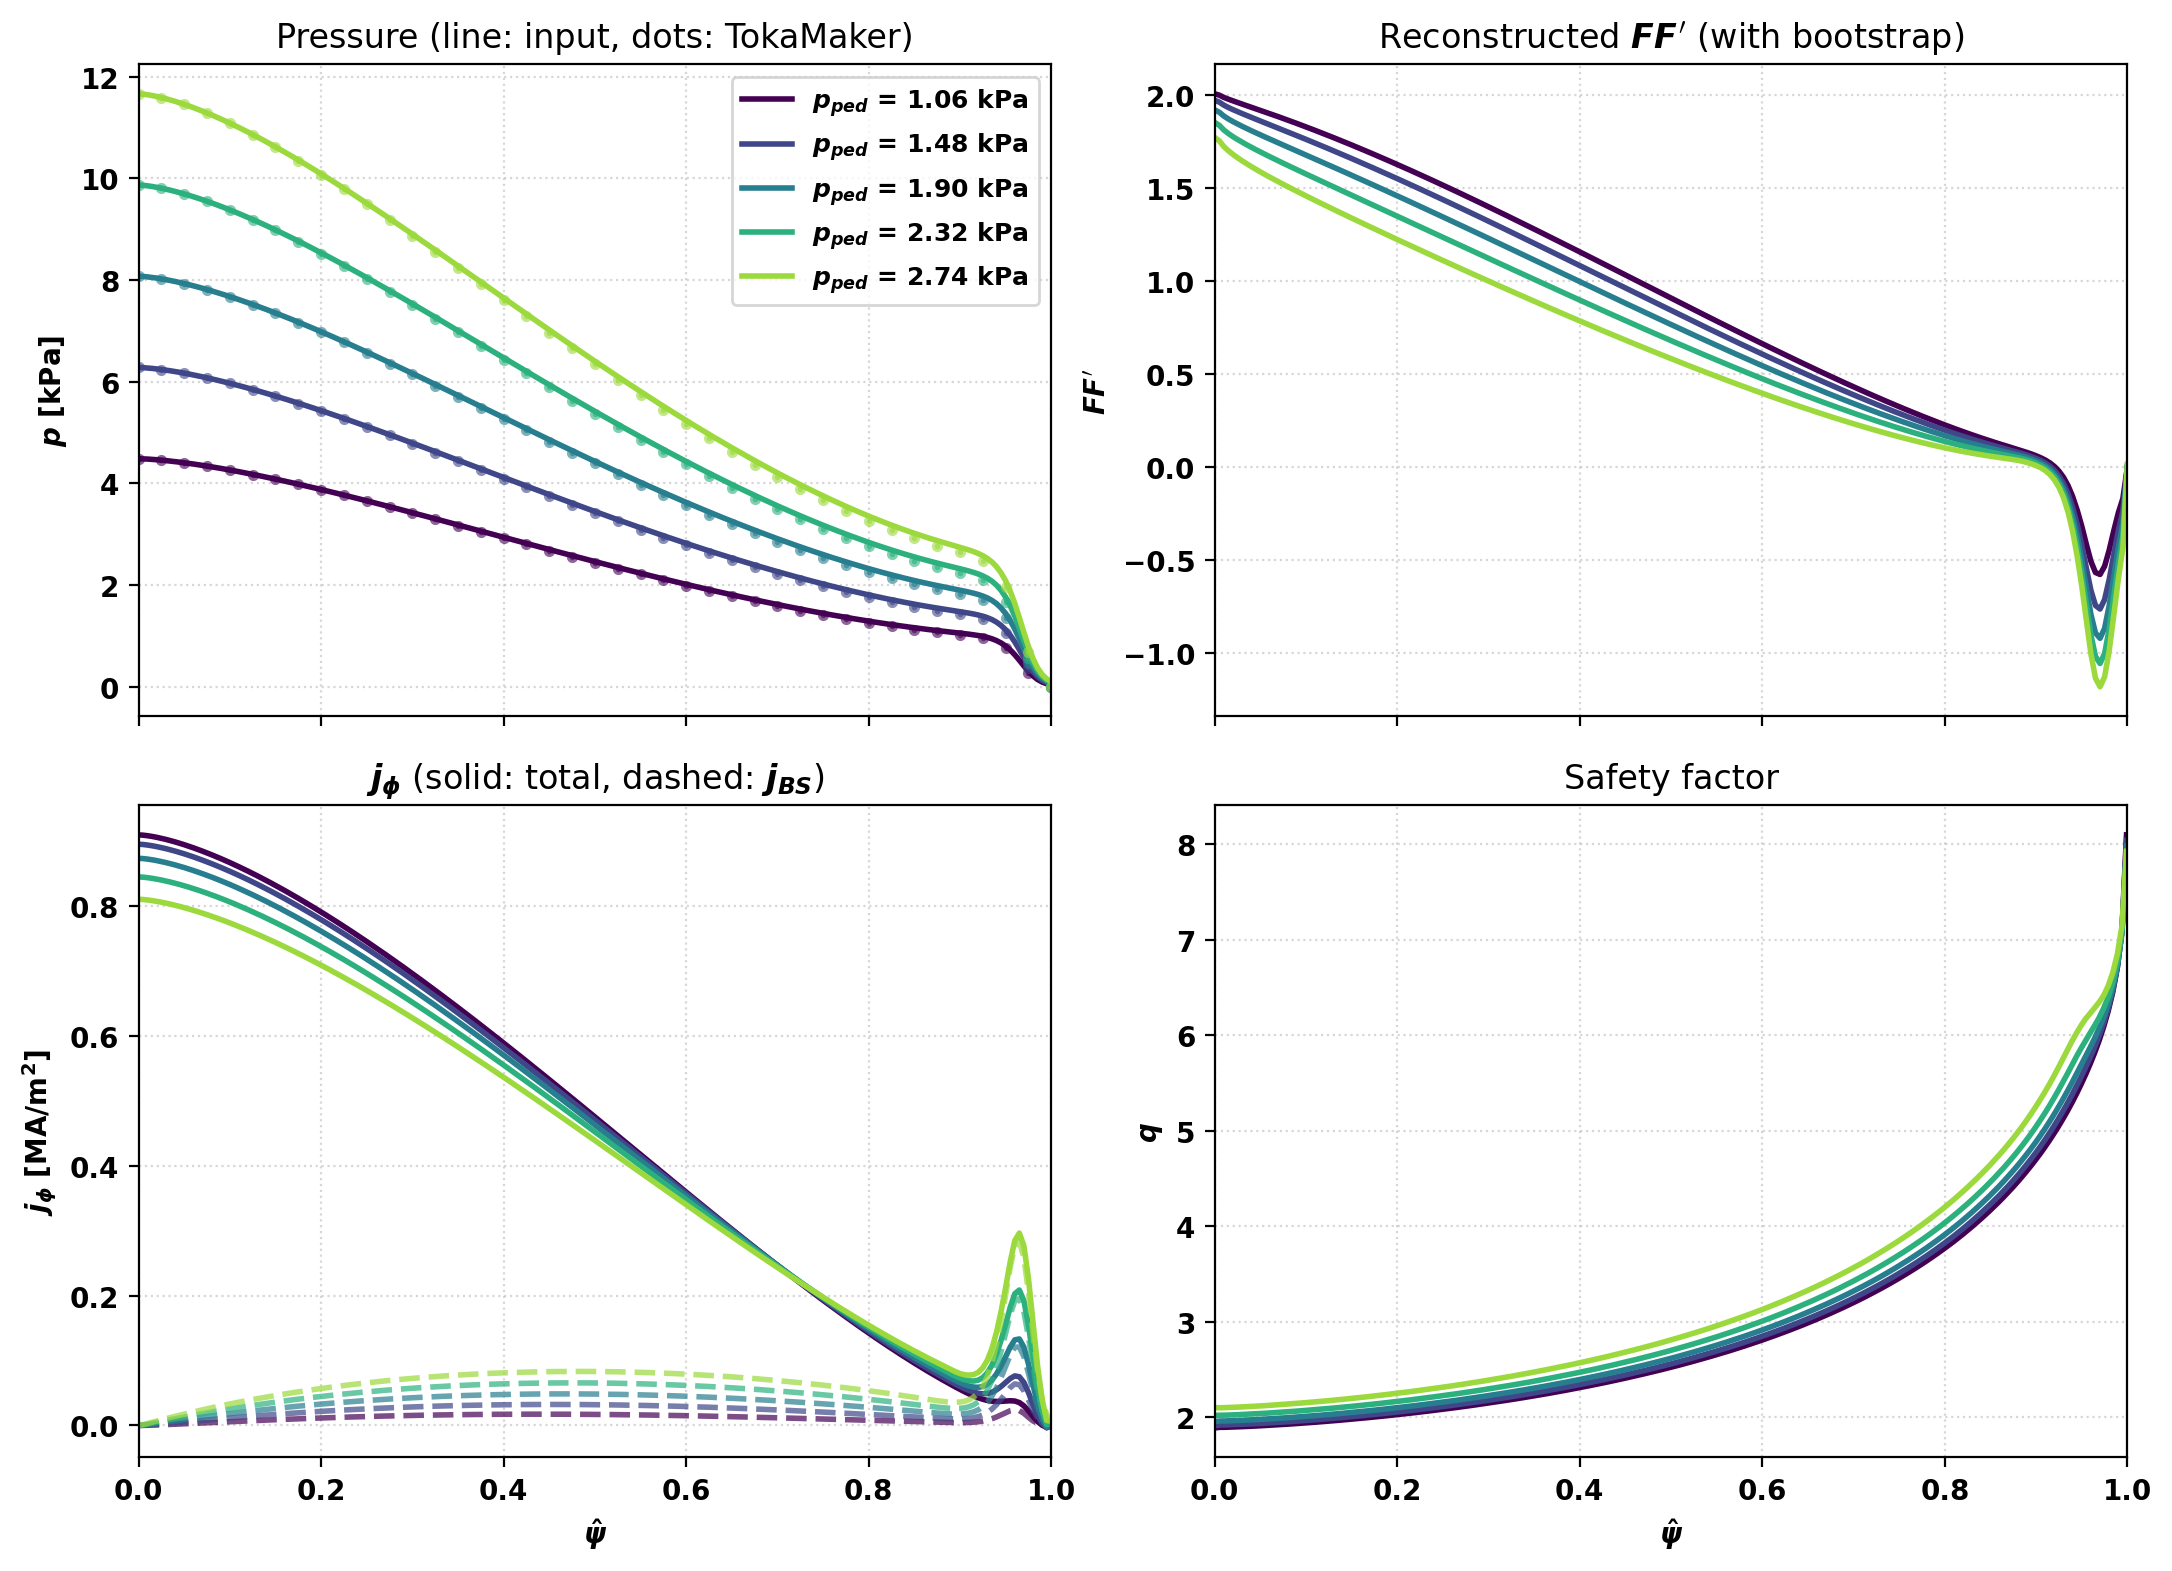

In [17]:
fig, ax = plt.subplots(2,2,figsize=(11,8),sharex=True)
for result, color in zip(scan_results,colors):
    label = r'$p_{{ped}}$ = {0:.2F} kPa'.format(result['p_ped']/1.E3)
    # Input pressure (line) and TokaMaker output pressure (dots)
    ax[0,0].plot(psi_N, result['pressure']/1.E3, color=color, label=label)
    ax[0,0].plot(result['psi'][::5], result['p_out'][::5]/1.E3, '.', color=color, ms=4, alpha=0.6)
    # Bootstrap-consistent FF' reconstruction
    ax[0,1].plot(result['psi'], result['ffp'], color=color)
    # Total j_phi (solid) and bootstrap contribution (dashed)
    ax[1,0].plot(psi_N, result['j_phi']/1.E6, color=color)
    ax[1,0].plot(psi_N, result['j_BS']/1.E6, '--', color=color, alpha=0.7)
    # Safety factor
    ax[1,1].plot(result['psi_q'], result['q'], color=color)
ax[0,0].set_ylabel(r'$p$ [kPa]')
ax[0,0].set_title('Pressure (line: input, dots: TokaMaker)')
ax[0,0].legend(fontsize=9)
ax[0,1].set_ylabel(r"$FF'$")
ax[0,1].set_title(r"Reconstructed $FF'$ (with bootstrap)")
ax[1,0].set_ylabel(r'$j_\phi$ [MA/m$^2$]')
ax[1,0].set_title(r'$j_\phi$ (solid: total, dashed: $j_{BS}$)')
ax[1,1].set_ylabel(r'$q$')
ax[1,1].set_title('Safety factor')
for axis in ax[1,:]:
    axis.set_xlabel(r'$\hat{\psi}$')
for axis in ax.flat:
    axis.set_xlim(0.0,1.0)
    axis.grid(ls=':',alpha=0.5)
fig.tight_layout()

In [18]:
print('{0:>12} {1:>10} {2:>10} {3:>11} {4:>9} {5:>7} {6:>7}'.format(
    'Te_ped [eV]','p_ped [kPa]','f_BS [%]','beta_pol [%]','beta_n [%]','l_i','q_95'))
for result in scan_results:
    stats = result['stats']
    print('{0:>12.0F} {1:>10.2F} {2:>10.1F} {3:>11.1F} {4:>9.2F} {5:>7.2F} {6:>7.2F}'.format(
        result['Te_ped'], result['p_ped']/1.E3, 100.0*result['I_BS']/abs(stats['Ip']),
        stats['beta_pol'], stats['beta_n'], stats['l_i'], stats['q_95']))

 Te_ped [eV] p_ped [kPa]   f_BS [%] beta_pol [%] beta_n [%]     l_i    q_95
         100       1.06        3.0        26.4      0.31    1.16    5.50
         140       1.48        6.4        37.3      0.44    1.14    5.58
         180       1.90       10.6        48.4      0.57    1.11    5.70
         220       2.32       15.8        60.1      0.70    1.07    5.88
         260       2.74       21.9        72.5      0.83    1.03    6.12


### Infinite-n ballooning stability with GPEC

Each saved gEQDSK is now passed to GPEC either directly or through the small Julia driver `compute_ballooning_boundary.jl` that sits next to this notebook. For every flux surface of the GPEC radial grid the driver computes:
- `alpha`: the experimental normalized pressure-gradient drive $\alpha$ of the equilibrium,
- `alpha_critical`: the value of $\alpha$ at which the ballooning $\Delta'$ first changes sign, i.e. the first (low-$\alpha$) infinite-n stability boundary.Surfaces with $\alpha > \alpha_{crit}$ are ballooning unstable. 

The both methods use GPEC's `LocalStability.ballooning_alpha_boundary`, which stops the scan at the first crossing, and writes one `ballooning_boundary_<case>.json` per equilibrium next to the gEQDSK. 

**Note:** The first call pays Julia's JIT compilation cost, which can take a few minutes.

**Note:** When called directly through `juliacall` any messages that are output to the error stream will show up in red, however any `Info:` messages can be safely ignored.

In [19]:
def load_boundary(geqdsk_path):
    r'''Read a ballooning boundary JSON written by the driver (JSON null -> NaN)'''
    json_path = os.path.join(os.path.dirname(geqdsk_path),
                             'ballooning_boundary_{0}.json'.format(os.path.basename(geqdsk_path)))
    with open(json_path,'r') as handle:
        raw = json.load(handle)
    return {key: np.array([np.nan if value is None else value for value in array])
            for key, array in raw.items()}

# Pedestal region over which stability is judged
inner_psi_N = 0.8

def edge_overlap_ratio(boundary, inner_psi_N=inner_psi_N):
    r'''max(alpha/alpha_crit) over the pedestal region; > 1 means ballooning unstable'''
    mask = ((boundary['psi'] >= inner_psi_N)
            & np.isfinite(boundary['alpha']) & np.isfinite(boundary['alpha_critical']))
    if not mask.any():
        return np.nan
    return float(np.max(boundary['alpha'][mask]/boundary['alpha_critical'][mask]))

run_gpec_ballooning([result['geqdsk'] for result in scan_results])

Running GPEC as external process
  julia -t auto --project=/Users/hansec/Research/GPEC_julia compute_ballooning_boundary.jl ballooning_scan/g192185_Teped0100 ballooning_scan/g192185_Teped0140 ballooning_scan/g192185_Teped0180 ballooning_scan/g192185_Teped0220 ballooning_scan/g192185_Teped0260
Ballooning boundary: g192185_Teped0100
  saved: /Users/hansec/Research/OpenFUSIONToolkit/builds/GCC/MPI/install_release/examples/TokaMaker/AdvancedWorkflows/NT_Ballooning_GPEC/ballooning_scan/ballooning_boundary_g192185_Teped0100.json  (1025 surfaces)
Ballooning boundary: g192185_Teped0140
  saved: /Users/hansec/Research/OpenFUSIONToolkit/builds/GCC/MPI/install_release/examples/TokaMaker/AdvancedWorkflows/NT_Ballooning_GPEC/ballooning_scan/ballooning_boundary_g192185_Teped0140.json  (1025 surfaces)
Ballooning boundary: g192185_Teped0180
  saved: /Users/hansec/Research/OpenFUSIONToolkit/builds/GCC/MPI/install_release/examples/TokaMaker/AdvancedWorkflows/NT_Ballooning_GPEC/ballooning_scan/ballooning

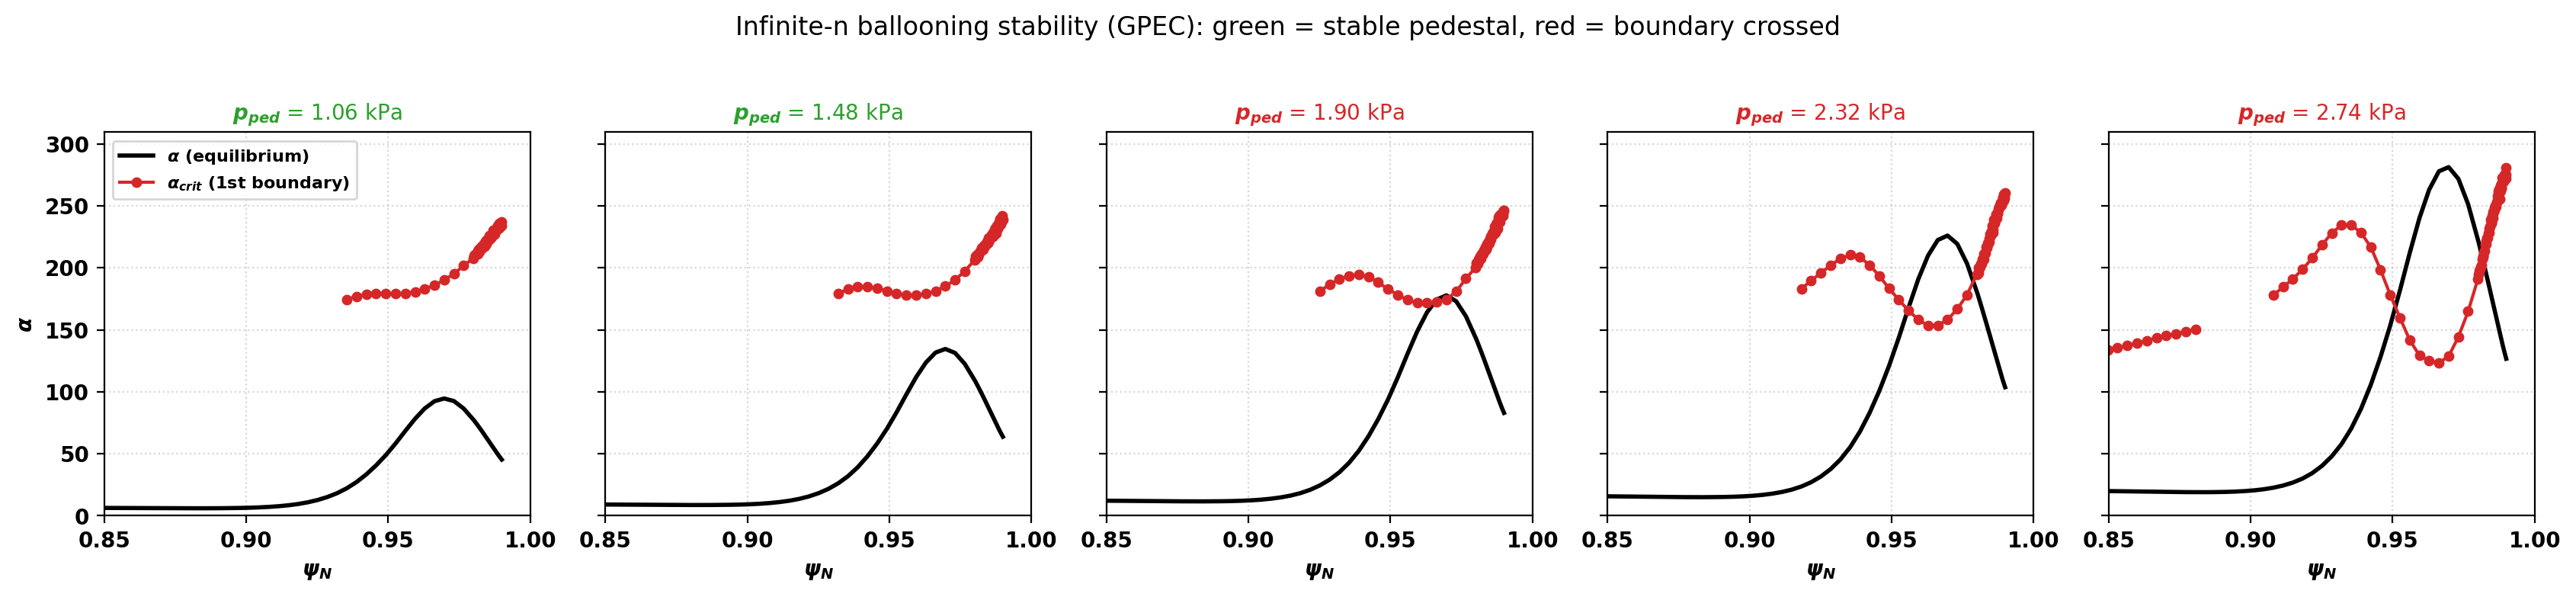

In [20]:
# Plots are zoomed to the pedestal region, where the boundary is crossed
psi_plot_min = 0.85

def plot_boundary(axis, boundary):
    r'''Plot alpha and the first ballooning boundary over the pedestal region'''
    axis.plot(boundary['psi'], boundary['alpha'], 'k-', label=r'$\alpha$ (equilibrium)')
    axis.plot(boundary['psi'], boundary['alpha_critical'], '-o', color='tab:red', ms=3, lw=1.5,
              label=r'$\alpha_{crit}$ (1st boundary)')
    axis.set_xlabel(r'$\psi_N$')
    axis.set_xlim(psi_plot_min,1.0)
    axis.grid(ls=':',alpha=0.5)

fig, ax = plt.subplots(1,len(scan_results),figsize=(3.4*len(scan_results),3.8),sharex=True,sharey=True)
alpha_max = 0.0
for axis, result in zip(ax,scan_results):
    boundary = load_boundary(result['geqdsk'])
    plot_boundary(axis,boundary)
    stable = edge_overlap_ratio(boundary) < 1.0
    axis.set_title(r'$p_{{ped}}$ = {0:.2F} kPa'.format(result['p_ped']/1.E3),fontsize=10,
                   color=('tab:green' if stable else 'tab:red'))
    in_view = (boundary['psi'] >= psi_plot_min)
    alpha_max = max(alpha_max, np.nanmax(boundary['alpha'][in_view]),
                    np.nanmax(boundary['alpha_critical'][in_view]))
ax[0].set_ylim(0.0,1.1*alpha_max)
ax[0].set_ylabel(r'$\alpha$')
ax[0].legend(loc='upper left',fontsize=8)
fig.suptitle('Infinite-n ballooning stability (GPEC): green = stable pedestal, red = boundary crossed',y=1.02)
fig.tight_layout()

### Extract the ballooning-limited pedestal height

For each equilibrium we reduce the boundary to the single number computed by `edge_overlap_ratio()` above: the largest value of $\alpha/\alpha_{crit}$ over the pedestal region $\psi_N \geq 0.8$. A value below one means the whole edge sits inside the first stable region; a value above one means the pedestal has crossed the ballooning boundary. Interpolating this ratio to one across the scan gives the marginal pedestal height, i.e. the estimate of the pedestal pressure this NT plasma can support. Surfaces where GPEC finds no boundary within the scan range are returned as `NaN` and are excluded from the ratio: they are stable at any $\alpha$ reached in the scan.

In [21]:
p_peds = np.array([result['p_ped'] for result in scan_results])
ratios = np.array([edge_overlap_ratio(load_boundary(result['geqdsk'])) for result in scan_results])

print('{0:>12} {1:>22} {2:>10}'.format('p_ped [kPa]','max(alpha/alpha_crit)','stable?'))
for p_ped, ratio in zip(p_peds,ratios):
    print('{0:>12.2F} {1:>22.3F} {2:>10}'.format(p_ped/1.E3, ratio, 'yes' if ratio < 1.0 else 'NO'))

def marginal_pedestal(p_peds, ratios):
    r'''Pedestal pressure where the edge overlap ratio first crosses unity'''
    valid = np.isfinite(ratios)
    p_valid, ratio_valid = p_peds[valid], ratios[valid]
    order = np.argsort(p_valid)
    p_valid, ratio_valid = p_valid[order], ratio_valid[order]
    unstable = np.where(ratio_valid >= 1.0)[0]
    if unstable.size == 0:
        raise ValueError('All cases are ballooning stable: extend the scan to higher pedestal heights')
    if unstable[0] == 0:
        raise ValueError('All cases are ballooning unstable: extend the scan to lower pedestal heights')
    i_cross = unstable[0]
    p_0, p_1 = p_valid[i_cross-1], p_valid[i_cross]
    r_0, r_1 = ratio_valid[i_cross-1], ratio_valid[i_cross]
    return p_0 + (1.0-r_0)*(p_1-p_0)/(r_1-r_0)

p_ped_marginal = marginal_pedestal(p_peds,ratios)
Te_ped_marginal = float(np.interp(p_ped_marginal,p_peds,Te_peds))
print('\nBallooning-limited pedestal: p_ped = {0:.2F} kPa (Te_ped = {1:.0F} eV)'.format(
    p_ped_marginal/1.E3, Te_ped_marginal))

 p_ped [kPa]  max(alpha/alpha_crit)    stable?
        1.06                  0.498        yes
        1.48                  0.726        yes
        1.90                  1.018         NO
        2.32                  1.447         NO
        2.74                  2.253         NO

Ballooning-limited pedestal: p_ped = 1.87 kPa (Te_ped = 177 eV)


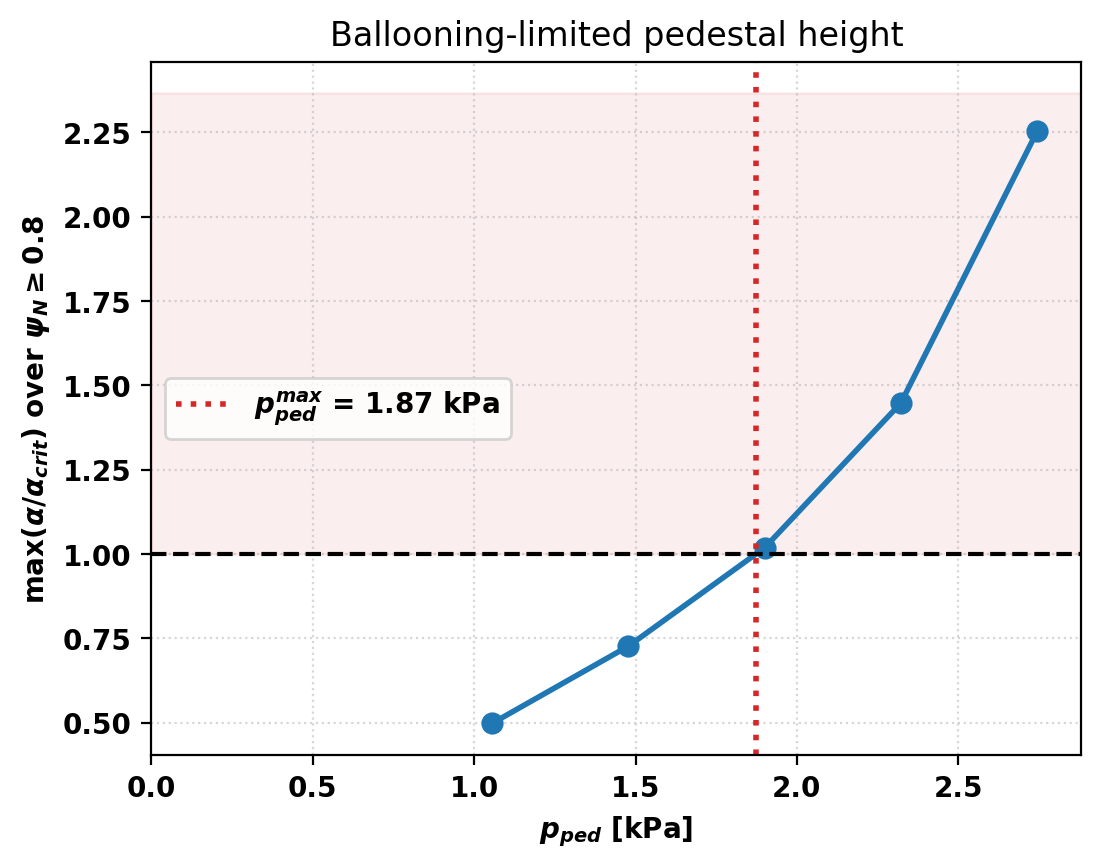

In [22]:
fig, ax = plt.subplots(1,1,figsize=(6,4.5))
ax.plot(p_peds/1.E3, ratios, 'o-', color='tab:blue')
ax.axhline(1.0, color='k', ls='--', lw=1.5)
ax.axvline(p_ped_marginal/1.E3, color='tab:red', ls=':', lw=2,
           label=r'$p_{{ped}}^{{max}}$ = {0:.2F} kPa'.format(p_ped_marginal/1.E3))
ax.fill_between([0.0,1.05*p_peds.max()/1.E3],[1.0,1.0],[max(1.05*np.nanmax(ratios),1.2)]*2,
                color='tab:red',alpha=0.08)
ax.set_xlabel(r'$p_{ped}$ [kPa]')
ax.set_ylabel(r'max$(\alpha/\alpha_{crit})$ over $\psi_N \geq $'+'{0}'.format(inner_psi_N))
ax.set_xlim(0.0,1.05*p_peds.max()/1.E3)
ax.set_title('Ballooning-limited pedestal height')
ax.grid(ls=':',alpha=0.5)
_ = ax.legend()

### Verify the marginal case

Finally we solve one more bootstrap-consistent equilibrium at the interpolated marginal pedestal temperature and run it through GPEC. If the interpolation is a good estimate, the $\alpha$ profile of this equilibrium should just touch the first ballooning boundary in the pedestal, i.e. $\max(\alpha/\alpha_{crit}) \approx 1$.

In [23]:
print('===== Marginal case: Te_ped = {0:.0F} eV ====='.format(Te_ped_marginal))
marginal_result = solve_pedestal_case(Te_ped_marginal,'192185_marginal')
run_gpec_ballooning([marginal_result['geqdsk']])
marginal_boundary = load_boundary(marginal_result['geqdsk'])
print('\np_ped = {0:.2F} kPa, max(alpha/alpha_crit) = {1:.3F}'.format(
    marginal_result['p_ped']/1.E3, edge_overlap_ratio(marginal_boundary)))

===== Marginal case: Te_ped = 177 eV =====
Saving gEQDSK: ballooning_scan/g192185_marginal
Running GPEC as external process
  julia -t auto --project=/Users/hansec/Research/GPEC_julia compute_ballooning_boundary.jl ballooning_scan/g192185_marginal
Ballooning boundary: g192185_marginal
  saved: /Users/hansec/Research/OpenFUSIONToolkit/builds/GCC/MPI/install_release/examples/TokaMaker/AdvancedWorkflows/NT_Ballooning_GPEC/ballooning_scan/ballooning_boundary_g192185_marginal.json  (1025 surfaces)


p_ped = 1.87 kPa, max(alpha/alpha_crit) = 0.997


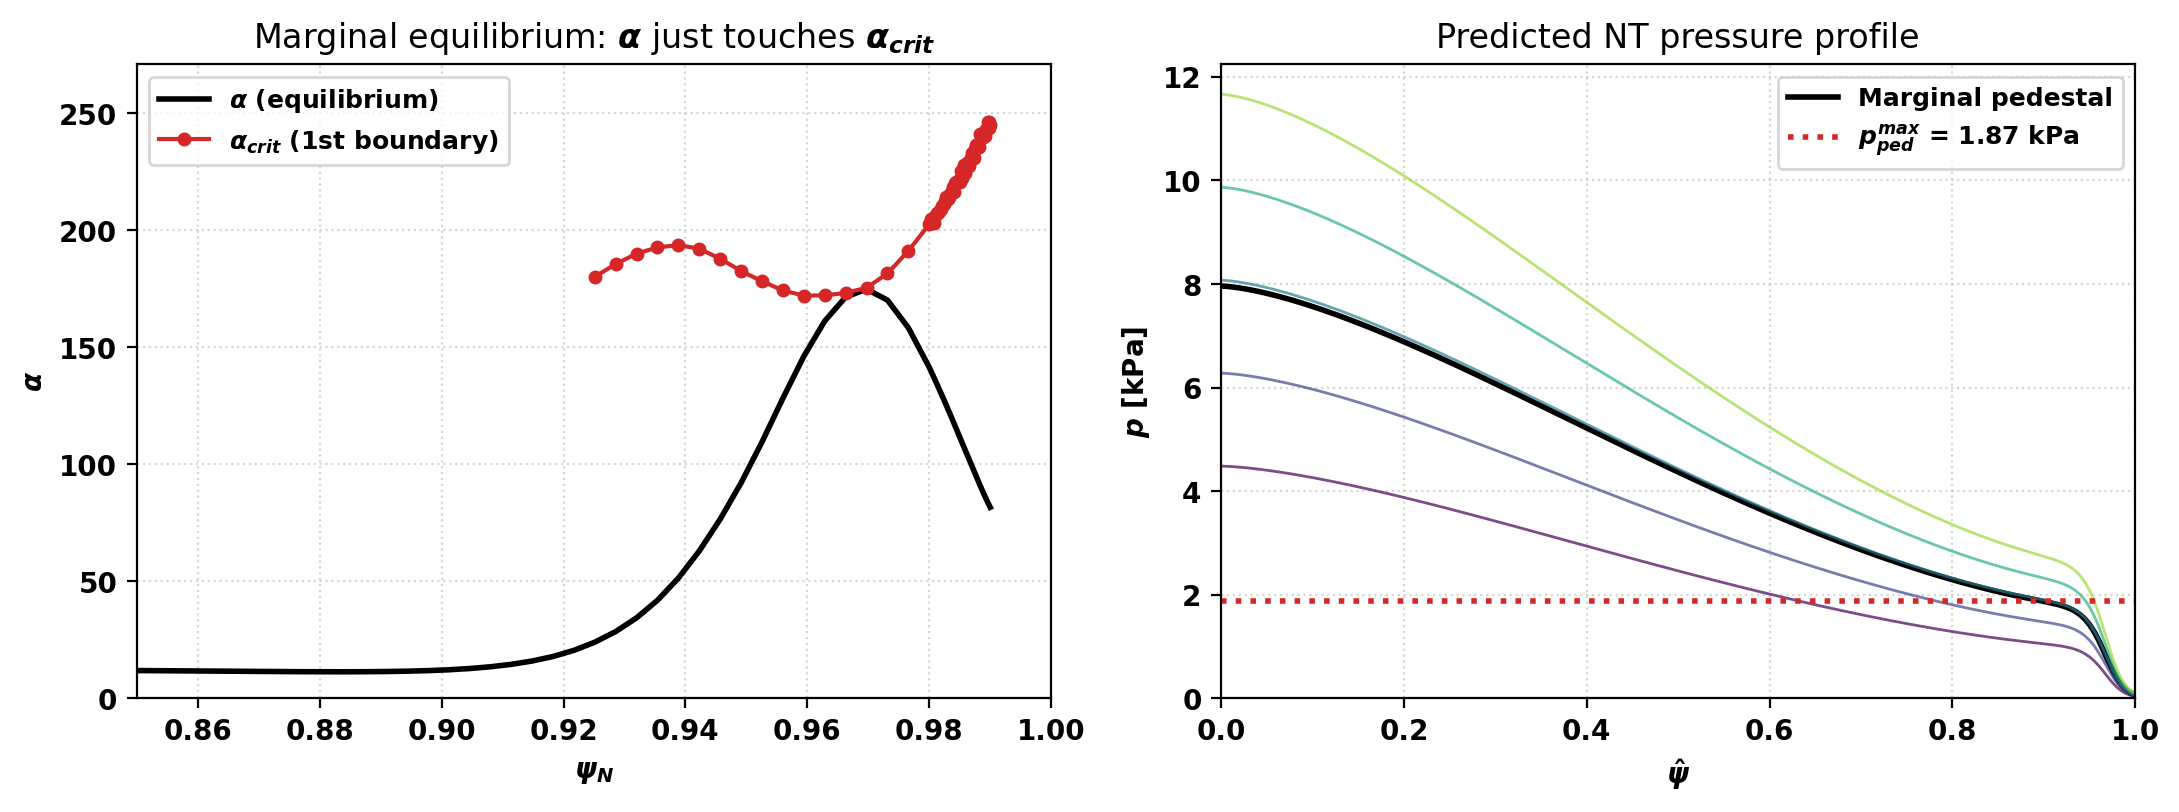

In [24]:
fig, ax = plt.subplots(1,2,figsize=(11,4.2))
plot_boundary(ax[0],marginal_boundary)
in_view = (marginal_boundary['psi'] >= psi_plot_min)
ax[0].set_ylim(0.0,1.1*max(np.nanmax(marginal_boundary['alpha'][in_view]),
                           np.nanmax(marginal_boundary['alpha_critical'][in_view])))
ax[0].set_ylabel(r'$\alpha$')
ax[0].set_title(r'Marginal equilibrium: $\alpha$ just touches $\alpha_{crit}$')
ax[0].legend(loc='upper left',fontsize=9)

ax[1].plot(psi_N, marginal_result['pressure']/1.E3, 'k-', label='Marginal pedestal')
for result, color in zip(scan_results,colors):
    ax[1].plot(psi_N, result['pressure']/1.E3, color=color, lw=1.0, alpha=0.7)
ax[1].axhline(marginal_result['p_ped']/1.E3, color='tab:red', ls=':', lw=2,
              label=r'$p_{{ped}}^{{max}}$ = {0:.2F} kPa'.format(marginal_result['p_ped']/1.E3))
ax[1].set_xlabel(r'$\hat{\psi}$')
ax[1].set_ylabel(r'$p$ [kPa]')
ax[1].set_xlim(0.0,1.0)
ax[1].set_ylim(bottom=0.0)
ax[1].set_title('Predicted NT pressure profile')
ax[1].legend(fontsize=9)
for axis in ax:
    axis.grid(ls=':',alpha=0.5)
fig.tight_layout()